<a href="https://colab.research.google.com/github/lomnitzs-maker/sophia/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing modules
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# importing data sets
ids = pd.read_csv('https://raw.githubusercontent.com/lomnitzs-maker/sophia/refs/heads/main/tbi_dementia_ids_final_project%20(1).csv')
pathology = pd.read_csv('https://raw.githubusercontent.com/lomnitzs-maker/sophia/refs/heads/main/tbi_dementia_pathology_final_project%20(1).csv')

In [3]:
# seeing how many males and females are in the study
ids['sex'].value_counts()


,count
sex,
M,63
F,44


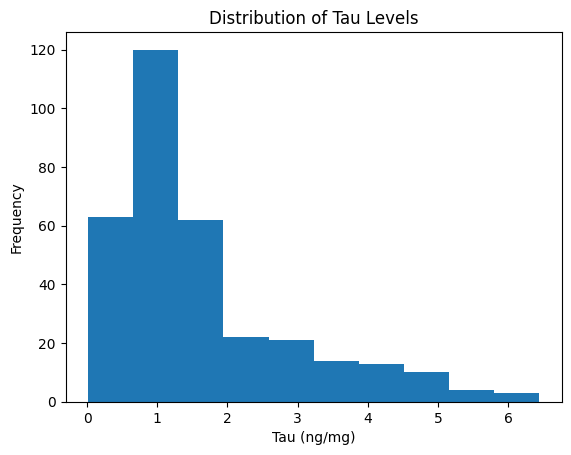

In [4]:
# making histogram for pTau levels
plt.hist(pathology['ptau_ng_per_mg'])
plt.xlabel("Tau (ng/mg)")
plt.ylabel("Frequency")
plt.title("Distribution of Tau Levels")
plt.show()

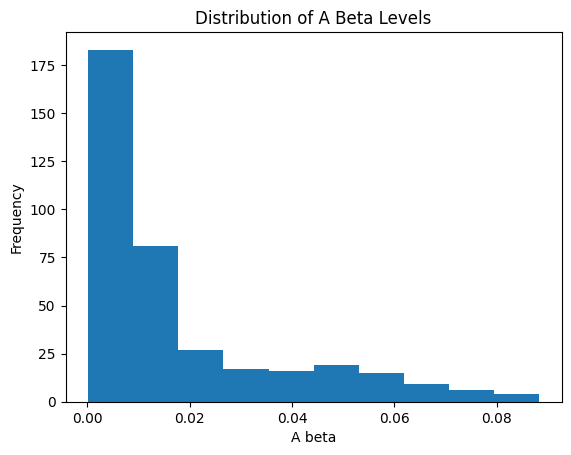

In [5]:
# making histogram for amyloid beta levels
plt.hist(pathology['ihc_a_beta'])
plt.xlabel("A beta")
plt.ylabel("Frequency")
plt.title("Distribution of A Beta Levels")
plt.show()

In [6]:
#merging data and making it a variable
data = pd.merge(ids, pathology, on='donor_id')

In [36]:
#importing stats module, and conducting skewness test
from scipy.stats import skew
#SKEWNESS
skew_abeta = skew(data['ihc_a_beta'].dropna())
skew_ptau = skew(data['ptau_ng_per_mg'].dropna())
print(skew_abeta)
print(skew_ptau)

1.5102134570341057
1.4736720771511025


In [8]:
# making male and female variables
male = data[data['sex'] == 'M']
female = data[data['sex'] == 'F']

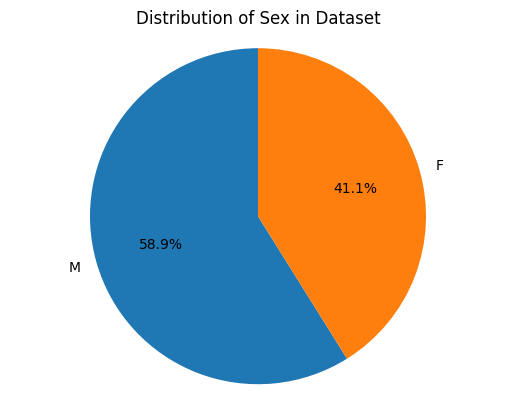

In [9]:
#making pie chart for men v woman
counts = data['sex'].value_counts()
plt.pie(
    counts,
    labels=counts.index,   # this will be ['M', 'F']
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Sex in Dataset")
plt.axis('equal')  # makes it a circle

plt.show()

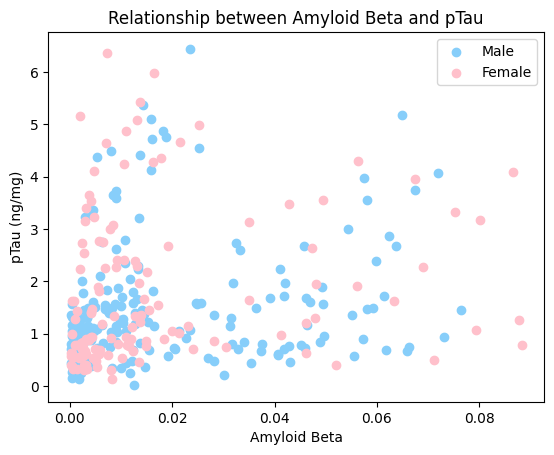

In [11]:
# making scatter plot to show relationship between two dependent variables
plt.scatter(
    male['ihc_a_beta'],
    male['ptau_ng_per_mg'],
    color='lightskyblue',
    label='Male'
)

plt.scatter(
    female['ihc_a_beta'],
    female['ptau_ng_per_mg'],
    color='pink',
    label='Female'
)

plt.xlabel("Amyloid Beta")
plt.ylabel("pTau (ng/mg)")
plt.title("Relationship between Amyloid Beta and pTau")
plt.legend()
plt.show()

In [45]:
# FINDING CORRELATION VALUES

from scipy.stats import pearsonr

corr_data = data[['ihc_a_beta', 'ptau_ng_per_mg']].dropna()

corr, p_corr = pearsonr(
    corr_data['ihc_a_beta'],
    corr_data['ptau_ng_per_mg']
)

print(corr, p_corr)

0.17524598783155526 0.0013462411800299727


/tmp/ipykernel_14351/3683455217.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


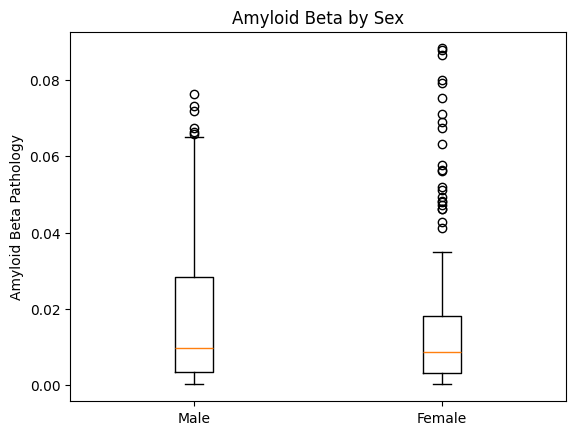

In [12]:
# making box plot for amyloid beta
plt.boxplot(
    [male['ihc_a_beta'].dropna(), female['ihc_a_beta'].dropna()],
    labels=['Male', 'Female']
)

plt.ylabel("Amyloid Beta Pathology")
plt.title("Amyloid Beta by Sex")

plt.show()

In [46]:
# STATS TEST FOR AMYLOID BETA
from scipy.stats import ttest_ind

t_abeta, p_abeta = ttest_ind(
    male['ihc_a_beta'].dropna(),
    female['ihc_a_beta'].dropna()
)
print(t_abeta, p_abeta)

0.6797253998187346 0.49709771740729425


/tmp/ipykernel_14351/860977164.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


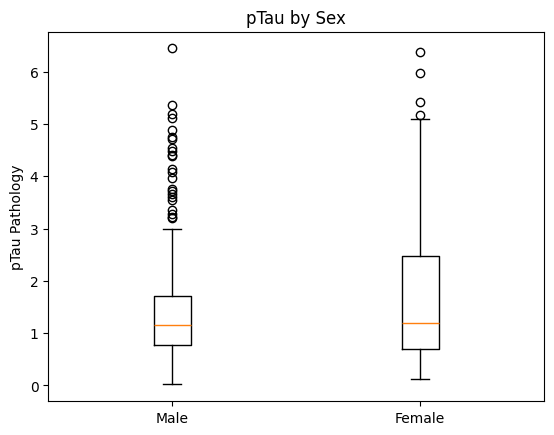

In [13]:
# making box plot for pTau
plt.boxplot(
    [male['ptau_ng_per_mg'].dropna(), female['ptau_ng_per_mg'].dropna()],
    labels=['Male', 'Female']
)

plt.ylabel("pTau Pathology")
plt.title("pTau by Sex")

plt.show()

In [47]:
# STATS TEST
t_ptau, p_ptau = ttest_ind(
    male['ptau_ng_per_mg'].dropna(),
    female['ptau_ng_per_mg'].dropna()
)
print(t_ptau,p_ptau)

-1.6421598294738033 0.10150943428391161


ANALYSIS TWO: Dementia vs il_4_pg_per_mg vs rantes_pg_per_mg

In [14]:
# finding out how many dementia patients vs patients w out dementia
ids['act_demented'].value_counts()

,count
act_demented,
No Dementia,57
Dementia,50


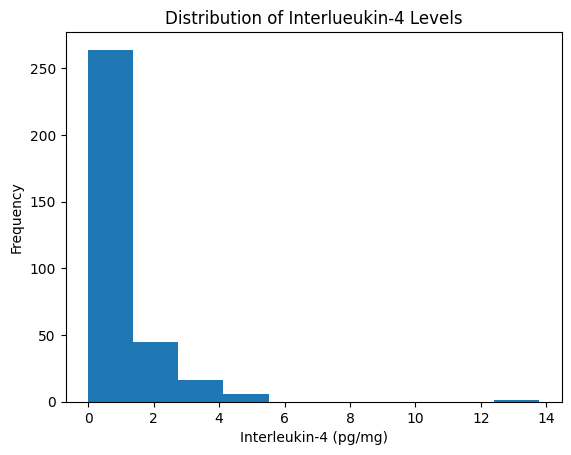

In [15]:
#making a histogram for IL-4 levels
plt.hist(pathology['il_4_pg_per_mg'])
plt.xlabel("Interleukin-4 (pg/mg)")
plt.ylabel("Frequency")
plt.title("Distribution of Interlueukin-4 Levels")
plt.show()

In [49]:
# conducting a skew test
skew_il4 = skew(data['il_4_pg_per_mg'].dropna())
skew_rantes = skew(data['rantes_pg_per_mg'].dropna())
print(skew_il4)

3.8676557432436853


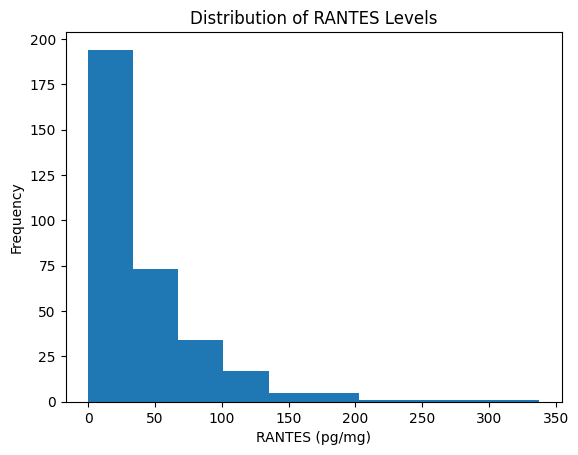

In [16]:
# making a histogram for RANTES levels
plt.hist(pathology['rantes_pg_per_mg'])
plt.xlabel("RANTES (pg/mg)")
plt.ylabel("Frequency")
plt.title("Distribution of RANTES Levels")
plt.show()

In [50]:
# conducting a skew test for rantes
print(skew_rantes)

2.5651518244746416


In [19]:
# making dementia v not dementia variables
dementia = data[data['act_demented'] == 'Dementia']
no_dementia = data[data['act_demented'] == 'No Dementia']

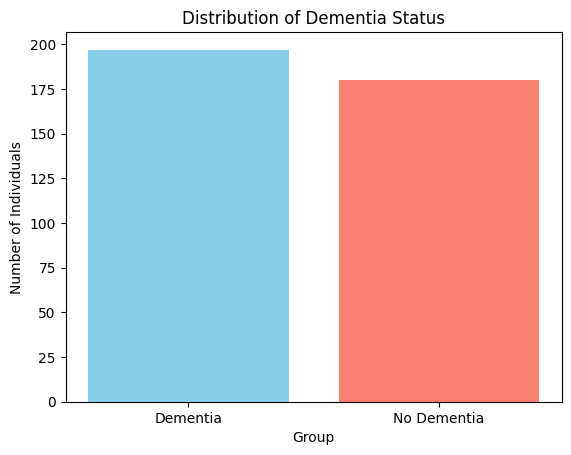

In [17]:
#making a bar graph to show patients w vs w out dementia
counts = data['act_demented'].value_counts()
plt.bar(['Dementia', 'No Dementia'], counts, color=['skyblue','salmon'])

plt.xlabel("Group")
plt.ylabel("Number of Individuals")
plt.title("Distribution of Dementia Status")

plt.show()

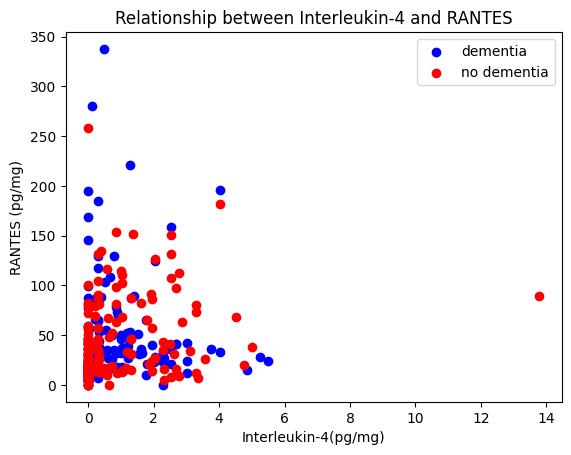

In [20]:
# making a scatter plot to show correlation between two dependent variables
plt.scatter(
    dementia['il_4_pg_per_mg'],
    dementia['rantes_pg_per_mg'],
    color='blue',
    label='dementia'
)

plt.scatter(
    no_dementia['il_4_pg_per_mg'],
    no_dementia['rantes_pg_per_mg'],
    color='red',
    label='no dementia'
)

plt.xlabel("Interleukin-4(pg/mg)")
plt.ylabel("RANTES (pg/mg)")
plt.title("Relationship between Interleukin-4 and RANTES")
plt.legend()
plt.show()

In [53]:
# CORRELATION TEST
corr, p_corr = pearsonr(
    data['il_4_pg_per_mg'].dropna(),
    data['rantes_pg_per_mg'].dropna()
)
print(corr, p_corr)

0.15853971173682455 0.0037774231319169104


/tmp/ipykernel_14351/359522373.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


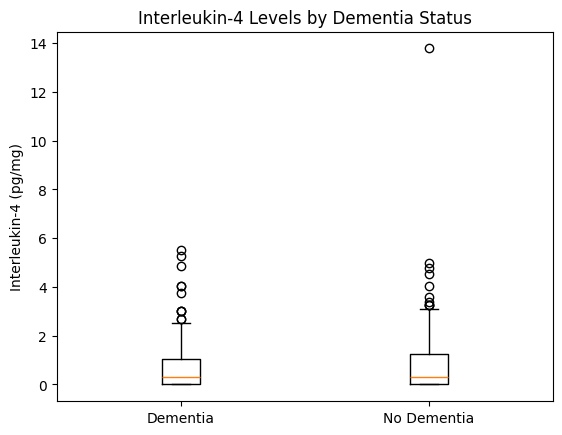

In [21]:
# making a box plot for IL-4
plt.boxplot(
    [dementia['il_4_pg_per_mg'].dropna(), no_dementia['il_4_pg_per_mg'].dropna()],
    labels=['Dementia', 'No Dementia']
)

plt.ylabel("Interleukin-4 (pg/mg)")
plt.title("Interleukin-4 Levels by Dementia Status")

plt.show()

/tmp/ipykernel_14351/1598357731.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


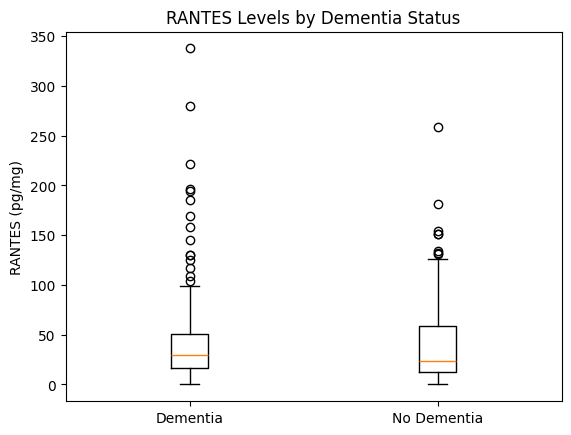

In [22]:
# making a box plot for RANTES
plt.boxplot(
    [dementia['rantes_pg_per_mg'].dropna(), no_dementia['rantes_pg_per_mg'].dropna()],
    labels=['Dementia', 'No Dementia']
)

plt.ylabel("RANTES (pg/mg)")
plt.title("RANTES Levels by Dementia Status")

plt.show()

In [25]:
# re-uploading modules
from scipy import stats
from scipy.stats import skew
from scipy.stats import pearsonr

In [55]:
# conducting t-test for IL-4
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(
    dementia['il_4_pg_per_mg'].dropna(),
    no_dementia['il_4_pg_per_mg'].dropna()
)
print(t_stat,p_val)

-0.8595446234292288 0.3906640801633763


In [54]:
# conducting a t-test for RANTES
t_stat, p_val = ttest_ind(
    dementia['rantes_pg_per_mg'].dropna(),
    no_dementia['rantes_pg_per_mg'].dropna()
)
print(t_stat,p_val)

0.800246931490665 0.4241434499982726
